# Energy variance & fidelity witness — prototype notebook

This notebook evaluates the Gaussian energy filter
$e^{-\beta (H-\lambda\mathbb{1})^2}$ and computes the **energy variance of $H$ as a function of
$\beta$**, then connects it to a **fidelity witness**.

**Idea in one line.** $e^{-\beta(H-\lambda)^2}$ is a Gaussian filter in energy: raising $\beta$
concentrates the state onto the eigenstate nearest $\lambda$, so its energy variance falls to
zero. A small energy variance *certifies* a large fidelity to that eigenstate:
$$F \;\ge\; 1 - \frac{\langle (H-E_0)^2\rangle}{\Delta^2},$$
with $\Delta$ the spectral gap. We watch both quantities as $\beta$ grows.


Only `numpy` and `matplotlib` are required.

Task: start on your own Github a prototype notebook evaluating exp(-\beta (H-\lambda * Id)^2) and caluclate the energy variance of H as a function of beta


## 1. Three-level toy model

The smallest system with a ground state, a gap, and a "far" level: energies $E=\{0,1,4\}$, filter
aimed at the ground state ($\lambda=0$, gap $\Delta=1$). For each $\beta$ we form the populations
$p_\mu \propto e^{-\beta(E_\mu-\lambda)^2}$ and compute the mean energy $\langle H\rangle$, the
**energy variance** $\mathrm{Var}(H)=\langle H^2\rangle-\langle H\rangle^2$, the **fidelity** to the
ground state $F=p_0$, and the **witness** $W=1-\langle H^2\rangle/\Delta^2$ (here $E_0=0$, so
$\langle(H-E_0)^2\rangle=\langle H^2\rangle$).

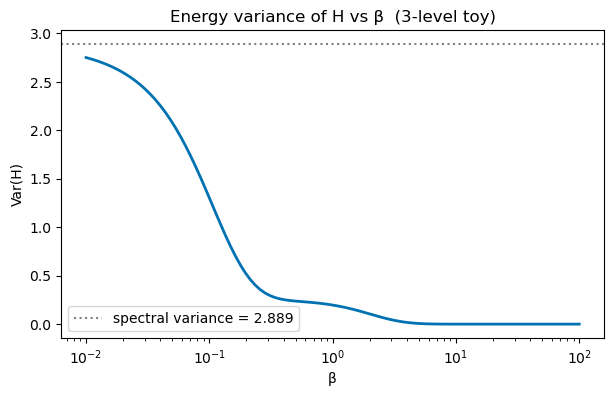

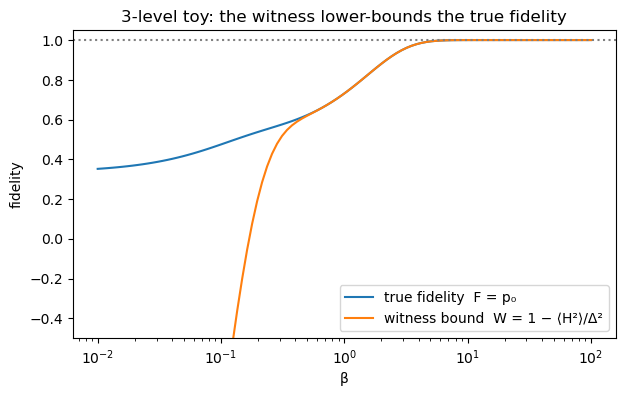

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# setup 
E   = np.array([0., 1., 4.])     # the three energies, chosen as 0,1,4
lam = 0.0                        # filter aimed at the ground state, lambda = 0.0
gap = E[1] - E[0]                # Δ = gap = 1

#  the function 
def moments(beta):
    w  = np.exp(-beta * (E - lam)**2)  
    p  = w / w.sum()          # populations
    Hexp = p @ E                 # <H>
    F  = p[0]                        # true fidelity = ground population
    H2 = p @ (E**2)                     # <H^2>
    W  = 1 - H2 / gap**2                # witness bound
    var = H2 - Hexp**2                   # var
    return F, var, H2, W

# plot as F vs beta
betas = np.logspace(-2, 2, 100)
F_vals, W_vals = [], []
for b in betas:
    F, var, H2, W = moments(b)      # four names for four returns, in order
    F_vals.append(F)
    W_vals.append(W)

betas = np.logspace(-2, 2, 100)
var_vals = [moments(b)[1] for b in betas]      # [1] = var

plt.figure(figsize=(7,4))
plt.semilogx(betas, var_vals, color="#0072B2", lw=2)
plt.axhline(E.var(), ls=":", color="gray", label=f"spectral variance = {E.var():.3f}")
plt.xlabel("β"); plt.ylabel("Var(H)")
plt.title("Energy variance of H vs β  (3-level toy)")
plt.legend(); plt.show()

plt.figure(figsize=(7, 4))
plt.semilogx(betas, F_vals, label="true fidelity  F = p₀")
plt.semilogx(betas, W_vals, label="witness bound  W = 1 − ⟨H²⟩/Δ²")
plt.axhline(1, ls=":", color="gray")
plt.ylim(-0.5, 1.05)
plt.xlabel("β"); plt.ylabel("fidelity")
plt.title("3-level toy: the witness lower-bounds the true fidelity")
plt.legend()
plt.show()

Table: A few values of $\beta$.

In [2]:
print(f"{'β':>7}  {'F':>8}  {'<H²>':>8}  {'W':>8}")
for b in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 20.0]:
    F, var, H2, W = moments(b)          # four returns; H2 is the 3rd
    print(f"{b:7.2f}  {F:8.4f}  {H2:8.4f}  {W:8.4f}")

      β         F      <H²>         W
   0.01    0.3518    5.1454   -4.1454
   0.05    0.4166    3.3911   -2.3911
   0.10    0.4747    1.9628   -0.9628
   0.50    0.6223    0.3808    0.6192
   1.00    0.7311    0.2689    0.7311
   2.00    0.8808    0.1192    0.8808
   5.00    0.9933    0.0067    0.9933
  20.00    1.0000    0.0000    1.0000


## 2. A real Hamiltonian: the tight-binding chain

The same method on a genuine physical spectrum — a 1D **tight-binding (nearest-neighbour
hopping) chain** of $N$ sites. The code builds its **single-particle Hamiltonian matrix**
directly,
$$H_{ij} = \begin{cases}-t & |i-j| = 1\\ 0 & \text{otherwise},\end{cases}$$
i.e. the tridiagonal matrix from `np.diag(...,1) + np.diag(...,-1)`, and takes its energy
levels from `np.linalg.eigvalsh(H)`. 

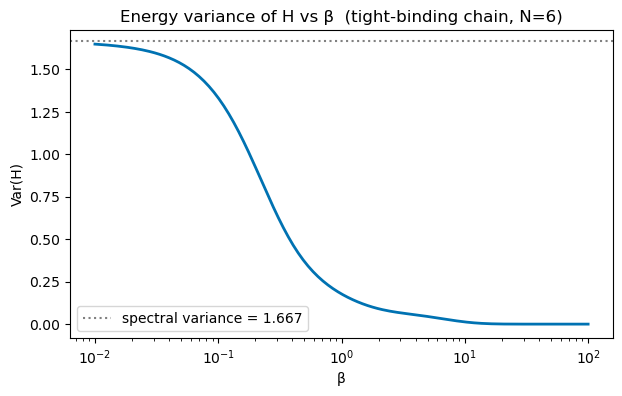

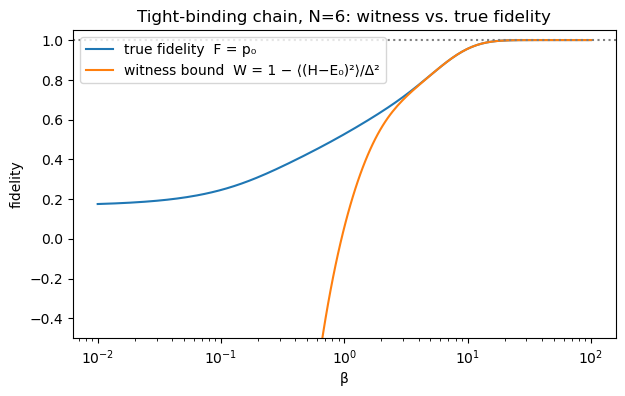

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# setup
N = 6
t = 1.0
H = -t * (np.diag(np.ones(N-1), 1) + np.diag(np.ones(N-1), -1))
E   = np.linalg.eigvalsh(H)
E0  = E[0]
gap = E[1] - E[0]
lam = E0

# function
def moments(beta):
    w    = np.exp(-beta * (E - lam)**2)
    p    = w / w.sum()                  # populations
    Hexp = p @ E                        # <H>
    H2   = p @ (E**2)                   # <H^2>
    mom2 = p @ (E - E0)**2              # <(H-E0)^2>   (witness input)
    var  = H2 - Hexp**2                 # Var(H) = <H^2> - <H>^2   (energy variance)
    F    = p[0]                         # fidelity = ground population
    W    = 1 - mom2 / gap**2            # witness bound
    return F, var, mom2, W

# 
betas = np.logspace(-2, 2, 200)
F_vals, W_vals, var_vals = [], [], []
for b in betas:
    F, var, mom2, W = moments(b)
    F_vals.append(F); W_vals.append(W); var_vals.append(var)

#variance
plt.figure(figsize=(7,4))
plt.semilogx(betas, var_vals, color="#0072B2", lw=2)
plt.axhline(E.var(), ls=":", color="gray", label=f"spectral variance = {E.var():.3f}")
plt.xlabel("β"); plt.ylabel("Var(H)")
plt.title(f"Energy variance of H vs β  (tight-binding chain, N={N})")
plt.legend(); plt.show()

# witness
plt.figure(figsize=(7, 4))
plt.semilogx(betas, F_vals, label="true fidelity  F = p₀")
plt.semilogx(betas, W_vals, label="witness bound  W = 1 − ⟨(H−E₀)²⟩/Δ²")
plt.axhline(1, ls=":", color="gray")
plt.ylim(-0.5, 1.05)
plt.xlabel("β"); plt.ylabel("fidelity")
plt.title(f"Tight-binding chain, N={N}: witness vs. true fidelity")
plt.legend(); plt.show()

**Table.** `Var(H)` and `mom2` $=\langle(H-E_0)^2\rangle$ (the witness input)
are now genuinely different columns, because $E_0\neq 0$.

In [4]:
print(f"{'β':>8}  {'F':>8}  {'Var(H)':>8}  {'<(H-E0)²>':>10}  {'W':>8}")
for b in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 20.0, 100.0]:
    F, var, mom2, W = moments(b)          # four names for four returns
    print(f"{b:8.2f}  {F:8.4f}  {var:8.4f}  {mom2:10.4f}  {W:8.4f}")

       β         F    Var(H)   <(H-E0)²>         W
    0.01    0.1749    1.6486      4.6848  -14.2114
    0.05    0.2073    1.5338      3.8409  -11.4713
    0.10    0.2455    1.3323      2.9688   -8.6395
    0.50    0.4261    0.3686      0.6436   -1.0899
    1.00    0.5263    0.1777      0.2904    0.0572
    2.00    0.6388    0.0905      0.1360    0.5584
    5.00    0.8234    0.0449      0.0545    0.8230
   20.00    0.9979    0.0006      0.0006    0.9979
  100.00    1.0000    0.0000      0.0000    1.0000


## 3. Smaller gap needs larger $\beta$

Increasing the chain length $N$ shrinks the gap $\Delta$.

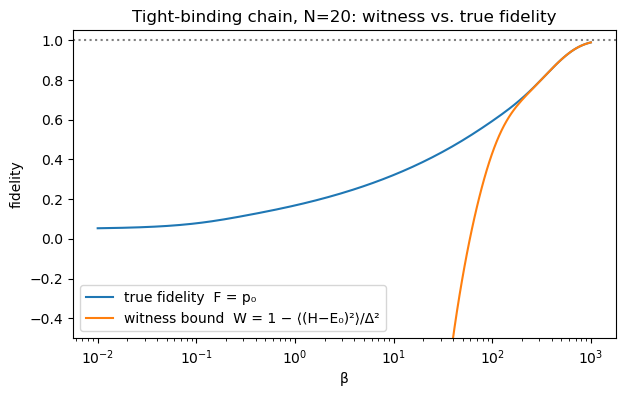

In [5]:
N = 20
t =1.0
H = -t * (np.diag(np.ones(N-1),1) + np.diag(np.ones(N-1), -1))
E = np.linalg.eigvalsh(H)

E0 = E[0]
gap = E[1] - E[0]
lam = E0

def moments(beta):
    w  = np.exp(-beta * (E - lam)**2)   # Gaussian weights
    p  = w / w.sum()                    # populations
    F  = p[0]                           # true fidelity = ground population
    mom2 = p @ (E - E0)**2                     # <H^2>
    W  = 1 - mom2 / gap**2                # witness bound
    return F, mom2, W

betas = np.logspace(-2, 3, 200)
F_vals, W_vals = [], []
for b in betas:
    F, mom2, W = moments(b)
    F_vals.append(F)
    W_vals.append(W)

plt.figure(figsize=(7, 4))
plt.semilogx(betas, F_vals, label="true fidelity  F = p₀")
plt.semilogx(betas, W_vals, label="witness bound  W = 1 − ⟨(H−E₀)²⟩/Δ²")
plt.axhline(1, ls=":", color="gray")
plt.ylim(-0.5, 1.05)
plt.xlabel("β"); plt.ylabel("fidelity")
plt.title(f"Tight-binding chain, N={N}: witness vs. true fidelity")
plt.legend(); plt.show()